# Exploratory Data Analysis – EDA
Phân tích bộ dữ liệu điểm thi THPT từ 2022-2026.

## 1. Setup & Load Data

In [13]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")
import viz

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df = viz.load_data("../data/processed/final_data.csv")
print("Shape:", df.shape)

Shape: (5359670, 28)


In [3]:
df.head()

,nam,chuong_trinh,sbd,ma_tinh,ten_tinh,vung_mien,vung_3,ma_ngoai_ngu,toan,ngu_van,...,cong_nghe_cn,cong_nghe_nn,gd_ktpl,so_mon,ban,diem_khoi_a00,diem_khoi_a01,diem_khoi_b00,diem_khoi_c00,diem_khoi_d01
0,2022,2006,01000001,01,Hà Nội,Đồng bằng sông Hồng,Bắc,NA,3.6,5.00,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,13.75,12.60
1,2022,2006,01000002,01,Hà Nội,Đồng bằng sông Hồng,Bắc,NA,8.4,6.75,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,22.75,22.75
2,2022,2006,01000003,01,Hà Nội,Đồng bằng sông Hồng,Bắc,NA,5.8,7.50,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,20.25,18.30
3,2022,2006,01000004,01,Hà Nội,Đồng bằng sông Hồng,Bắc,NA,7.4,7.50,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,21.50,23.50
4,2022,2006,01000005,01,Hà Nội,Đồng bằng sông Hồng,Bắc,NA,7.2,8.50,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,25.00,24.70


## 2. Tổng quan & dữ liệu thiếu
Quan sát tỷ lệ dữ liệu bị khuyết (nghĩa là không dự thi môn đó) và phân bố tổng số môn thi của các thí sinh.

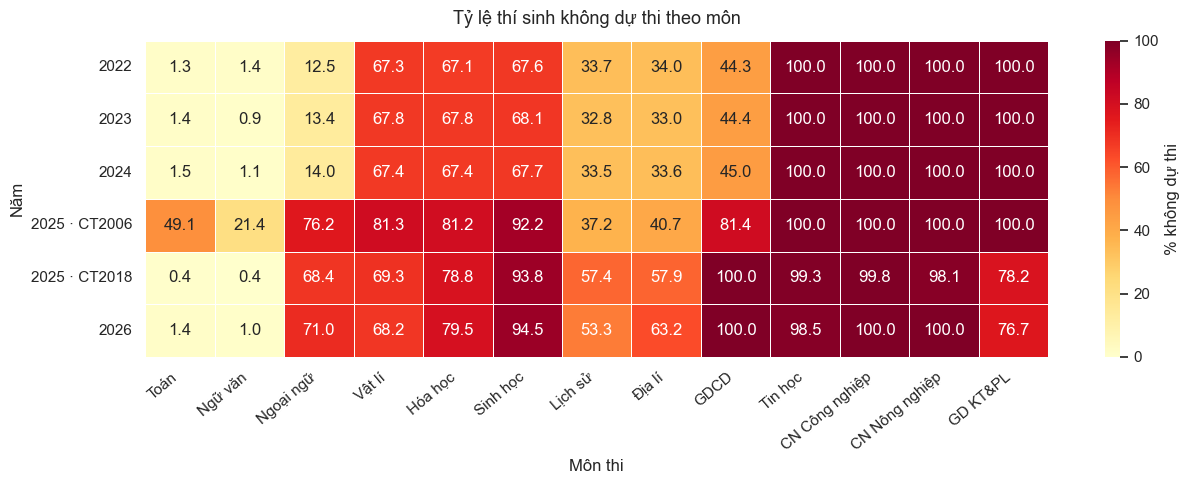

In [4]:
viz.plot_missing_heatmap(df)
plt.show()

**Nhận xét**

- **Toán** và **Ngữ văn** có độ phủ cao nhất ở hầu hết các năm. Giai đoạn **2022–2024**, tỷ lệ khuyết chỉ khoảng **1.0–1.5%**; đến **CT2018 (2025)** và **2026** vẫn gần như phủ toàn bộ thí sinh.
- **Ngoại ngữ** có xu hướng khuyết tăng dần: **12.5% (2022)** → **14.0% (2024)** → **68.4% (CT2018 - 2025)** → **71.0% (2026)**, cho thấy môn này giảm vai trò rõ rệt khi không còn bắt buộc.
- Trong **2022–2024**, nhóm **KHTN** (**Vật lí, Hóa học, Sinh học**) có tỷ lệ khuyết rất cao, khoảng **67–68%**, tức chỉ khoảng **1/3 thí sinh** lựa chọn.
- Cùng giai đoạn, nhóm **KHXH** (**Lịch sử, Địa lí, GDCD**) có tỷ lệ khuyết thấp hơn, khoảng **33–45%**, phản ánh xu hướng thí sinh **nghiêng về KHXH** nhiều hơn KHTN.
- **CT2006 (2025)** có tỷ lệ khuyết cao ở gần như mọi môn, kể cả **Toán (49.1%)** và **Ngữ văn (21.4%)**, phù hợp với đặc điểm nhóm **thí sinh tự do/thi lại**, chỉ đăng ký các môn cần thiết.
- **CT2018 (2025)** cho thấy sự phân hóa mạnh: **Toán** và **Ngữ văn** vẫn phủ gần tuyệt đối, trong khi nhiều môn còn lại có tỷ lệ khuyết rất cao.
- Sang **2026**, xu hướng phân hóa tiếp tục rõ hơn: **Vật lí** khuyết **68.2%**, **Hóa học** **79.5%**, **Sinh học** **94.5%**; phía KHXH, **Lịch sử** khuyết **53.3%**, **Địa lí** **63.2%**.
- Các môn mới của chương trình **CT2018** vẫn có tỷ lệ khuyết rất cao trong **2025–2026**: **Tin học** gần **99%**, **Công nghệ CN/NN** gần như **100%**, **GD KT&PL** khoảng **76–78%**.
- **GDCD** khuyết **100%** ở **CT2018 (2025)** và **2026**, cho thấy môn này không còn xuất hiện như một môn thi độc lập trong chương trình mới.

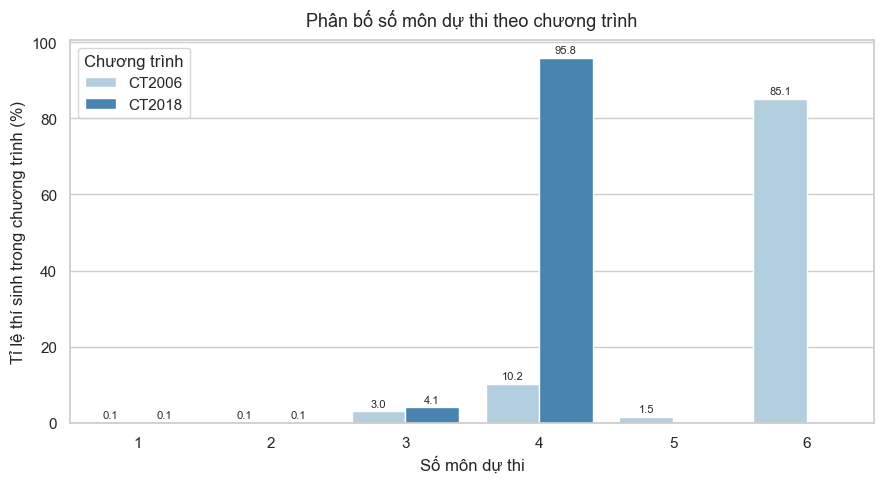

In [8]:
viz.plot_so_mon_dist(df)
plt.show()

**Nhận xét**

- **CT2006** tập trung chủ yếu ở **6 môn (85.1%)**, phản ánh phần lớn thí sinh dự thi theo cấu trúc truyền thống với số môn tương đối đầy đủ.
- Ở **CT2006**, nhóm thi **4 môn (10.2%)** và **5 môn (1.5%)** chiếm tỷ lệ nhỏ hơn, cho thấy vẫn tồn tại một bộ phận thí sinh chỉ đăng ký một phần số môn, nhiều khả năng là thí sinh tự do hoặc thi lại để phục vụ mục tiêu xét tuyển.
- **CT2018** tập trung gần như hoàn toàn ở **4 môn (95.8%)**, cho thấy số môn dự thi của thí sinh theo chương trình mới có mức độ tập trung rất cao và ít phân tán.
- Ngoài nhóm 4 môn, **CT2018** chỉ còn một tỷ lệ nhỏ ở **3 môn (4.1%)**, trong khi các mức khác gần như không đáng kể.
- So sánh hai chương trình cho thấy **mặt bằng số môn dự thi khác biệt rất rõ**: thí sinh **CT2006** chủ yếu thi **6 môn**, còn thí sinh **CT2018** chủ yếu thi **4 môn**. Vì vậy, các so sánh trực tiếp về **tổng điểm** hoặc **điểm trung bình trên toàn bộ môn thi** giữa hai chương trình cần được diễn giải thận trọng.
- Tỷ lệ thí sinh chỉ thi **1–2 môn** gần như bằng **0** ở cả hai chương trình, cho thấy các trường hợp đăng ký quá ít môn là rất hiếm.

## 3. Phổ điểm từng môn
Phân tích chi tiết phổ điểm, điểm liệt (<1).

In [9]:
display(viz.summary_score_by_subject_year(df))

,Năm,Môn,Số lượng thí sinh,Mean,Median,Std,% < 1 (Điểm liệt),% >= 8 (Khá giỏi),% = 10 (Tuyệt đối)
0,2022,GDCD,554343,8.033266,8.25,1.067272,0.004510,61.850154,0.511597
1,2022,Hóa học,327367,6.703898,7.00,1.600393,0.006109,27.872693,0.048264
2,2022,Lịch sử,659662,6.343930,6.50,1.612879,0.003335,18.130649,0.269684
3,2022,Ngoại ngữ,870609,5.157686,4.80,1.949547,0.016885,12.090043,0.063748
4,2022,Ngữ văn,981407,6.507746,6.50,1.379602,0.016914,16.972367,0.000509
5,2022,Sinh học,322198,5.019109,4.75,1.448270,0.014587,4.590035,0.001552
6,2022,Toán,982726,6.466254,6.80,1.675435,0.005597,21.849122,0.003562
7,2022,Vật lí,325523,6.723779,7.00,1.441925,0.003379,22.746473,0.047308
8,2022,Địa lí,657421,6.677929,6.75,1.215013,0.005172,16.726877,0.024794
9,2023,GDCD,565452,8.285805,8.50,1.137638,0.004244,68.954748,2.598452


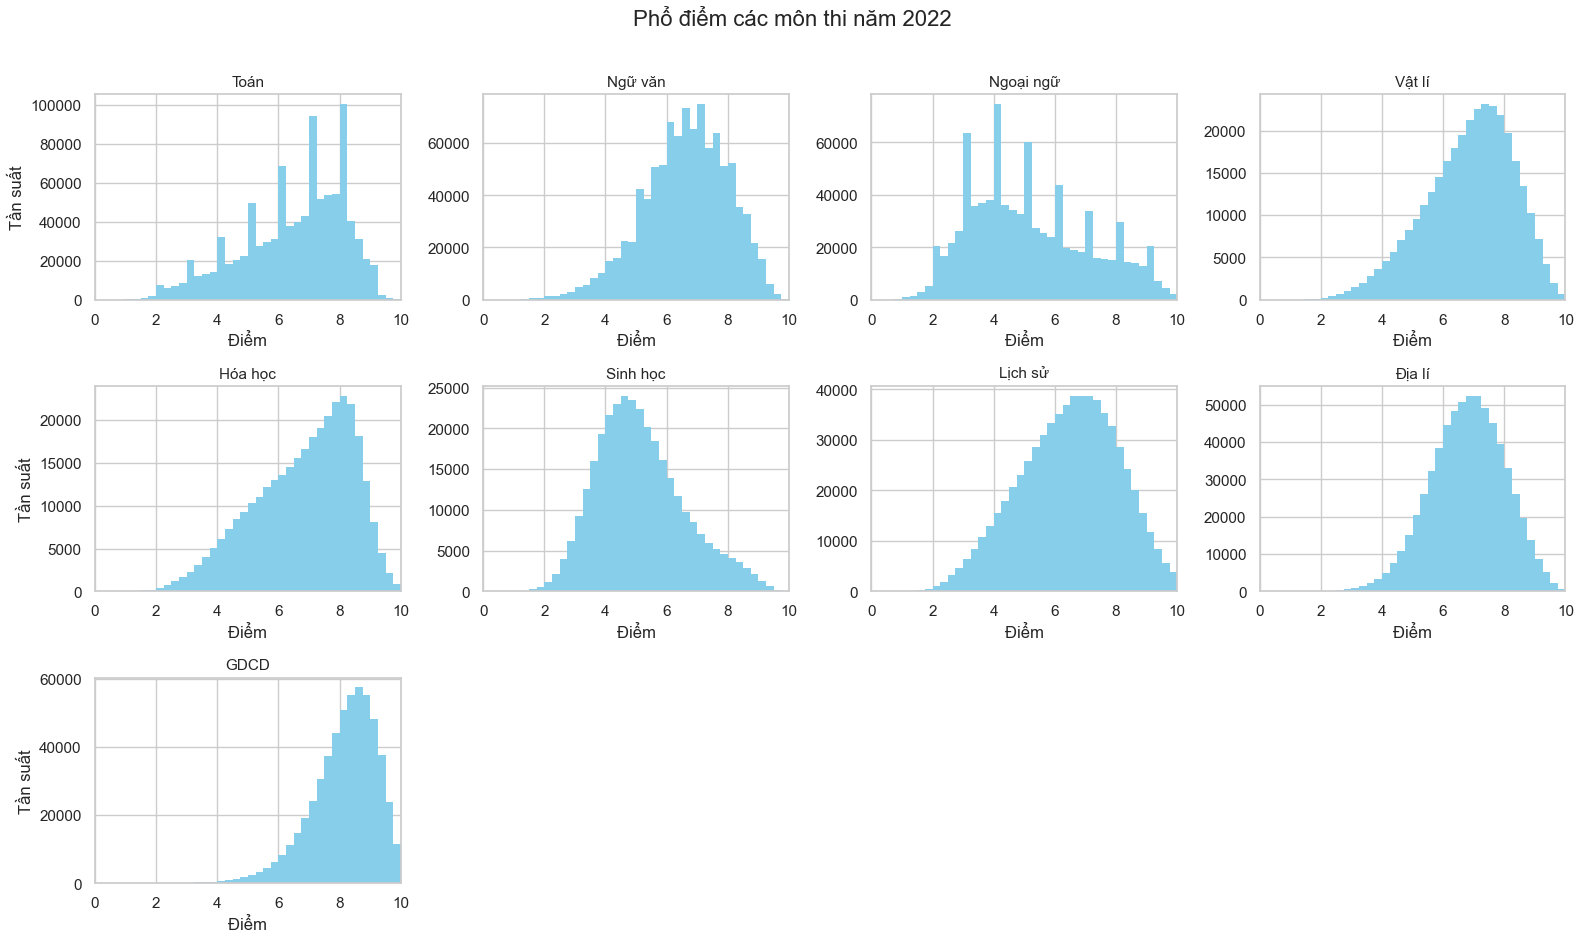

In [10]:
viz.plot_score_hist_grid(df, year=2022)
plt.show()

**Nhận xét, phổ điểm năm 2022.**

Phổ điểm hai môn Toán và Ngoại ngữ xuất hiện hiện tượng "răng cưa", với một số mức điểm có tần suất cao đột biến so với các mức lân cận. Đây là đặc trưng thường gặp ở các môn thi trắc nghiệm, do điểm được quy đổi từ số câu trả lời đúng nên một số giá trị điểm tập trung nhiều thí sinh hơn.

Trong các môn, Ngoại ngữ có phân bố kém cân đối nhất: phần lớn thí sinh đạt điểm trong khoảng 3–5, chỉ một bộ phận nhỏ đạt 8–10, tạo thành phổ lệch trái và có xu hướng tách thành hai cụm. Điều này phản ánh sự chênh lệch đáng kể về năng lực ngoại ngữ giữa các nhóm thí sinh. Môn Lịch sử cũng có mặt bằng điểm thấp, tập trung chủ yếu trong khoảng 4–6 với đỉnh phân bố thấp và trải rộng.

Ở chiều ngược lại, GDCD là môn có điểm cao nhất, với phần lớn thí sinh đạt 7–9 và gần như không có điểm thấp. Các môn Vật lí, Hóa học và Địa lí có phân bố tương đối cân đối, đỉnh nằm trong khoảng 7–8. Riêng Sinh học là môn thuộc nhóm khoa học tự nhiên nhưng có mặt bằng điểm thấp, phần lớn thí sinh chỉ đạt 4–5 điểm.

Ngữ văn có phân bố liên tục, không xuất hiện hiện tượng răng cưa, điểm tập trung quanh khoảng 6–7.

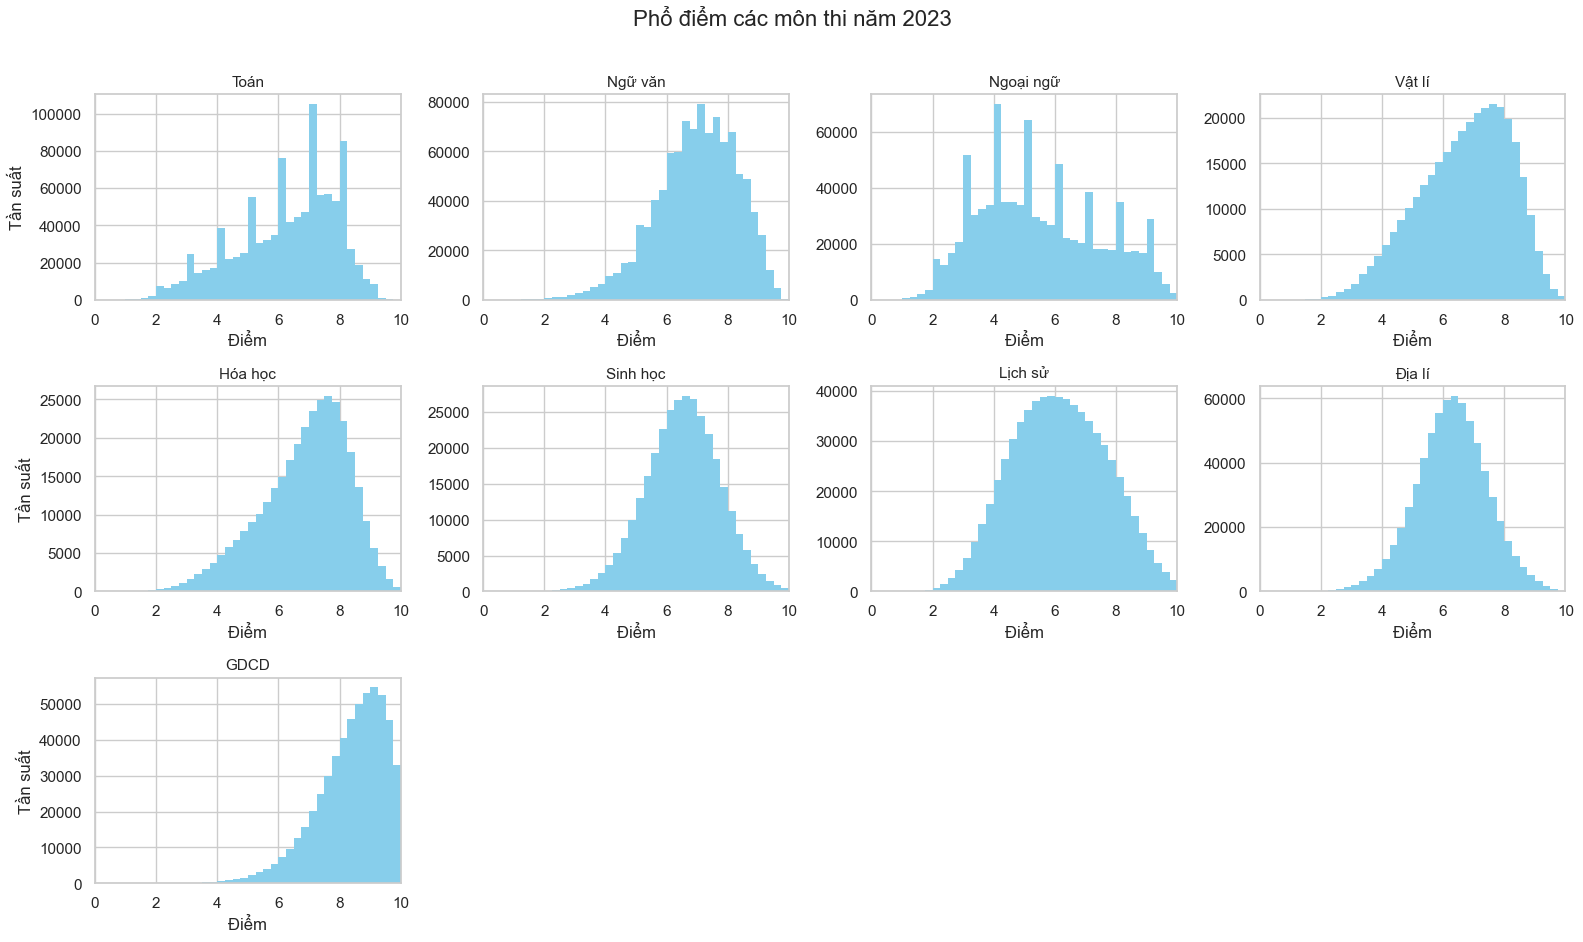

In [19]:
viz.plot_score_hist_grid(df, year=2023)
plt.show()

**Nhận xét, phổ điểm năm 2023.**

Phổ điểm năm 2023 nhìn chung giữ nguyên các đặc trưng đã thấy ở năm 2022. Hai môn Toán và Ngoại ngữ tiếp tục xuất hiện hiện tượng răng cưa, với một số mức điểm có tần suất cao đột biến so với các mức lân cận, do đặc thù quy đổi điểm của hình thức thi trắc nghiệm.

Ngoại ngữ vẫn là môn có phân bố kém cân đối nhất, điểm tập trung chủ yếu trong khoảng 3 đến 5 và chỉ một bộ phận nhỏ đạt 8 đến 10, tạo thành phổ lệch trái và có xu hướng tách cụm. Môn Lịch sử có mặt bằng điểm thấp, tập trung quanh khoảng 5 đến 6 với đỉnh phân bố thấp và trải rộng, tuy nhiên đã nhích cao hơn đôi chút so với năm 2022.

GDCD tiếp tục là môn có điểm cao nhất, phần lớn thí sinh đạt 8 đến 10 và gần như không có điểm thấp. Các môn Vật lí, Hóa học và Địa lí có phân bố tương đối cân đối, đỉnh nằm trong khoảng 7 đến 8. Riêng Sinh học năm nay có cải thiện rõ so với 2022, phổ điểm cân đối hơn và đỉnh dịch lên khoảng 6 đến 7, thay vì dồn ở vùng điểm thấp 4 đến 5 như năm trước.

Ngữ văn duy trì phân bố liên tục, không xuất hiện răng cưa, điểm tập trung quanh khoảng 6 đến 8.

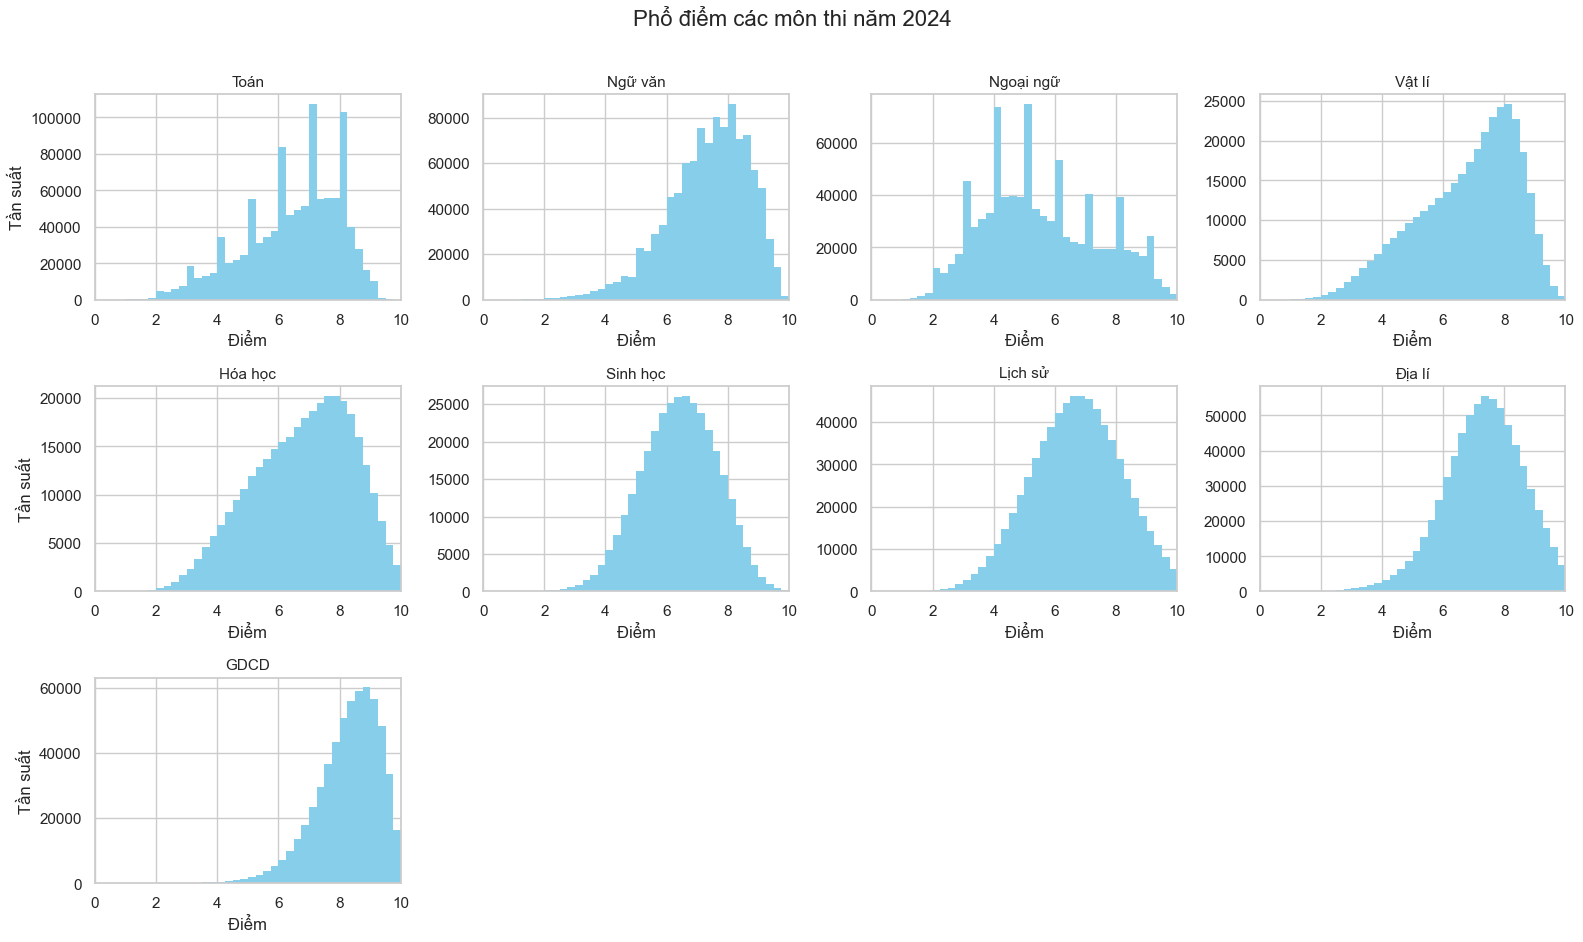

In [20]:
viz.plot_score_hist_grid(df, year=2024)
plt.show()

**Nhận xét, phổ điểm năm 2024.**

Phổ điểm năm 2024 tiếp tục duy trì các đặc trưng chung của giai đoạn 2022 đến 2024. Hai môn Toán và Ngoại ngữ vẫn xuất hiện hiện tượng răng cưa, với một số mức điểm có tần suất cao đột biến so với các mức lân cận, do đặc thù quy đổi điểm của hình thức thi trắc nghiệm.

Ngoại ngữ vẫn là môn có phân bố kém cân đối nhất, điểm tập trung chủ yếu trong khoảng 3 đến 5 và chỉ một bộ phận nhỏ đạt 8 đến 10, giữ nguyên dáng phổ lệch trái và có xu hướng tách cụm như các năm trước. Môn Lịch sử có sự cải thiện rõ rệt so với 2022 và 2023, phổ điểm cân đối hơn và đỉnh dịch lên khoảng 6 đến 7, không còn lệch hẳn về vùng điểm thấp.

GDCD tiếp tục là môn có điểm cao nhất, phần lớn thí sinh đạt 8 đến 10 và gần như không có điểm thấp. Các môn Vật lí, Hóa học, Sinh học và Địa lí có phân bố tương đối cân đối, đỉnh nằm trong khoảng 7 đến 8, trong đó Sinh học giữ được mặt bằng điểm ổn định tương tự năm 2023.

Ngữ văn duy trì phân bố liên tục, không xuất hiện răng cưa, điểm tập trung quanh khoảng 7 đến 8 và có xu hướng nhích nhẹ về phía điểm cao so với các năm trước.

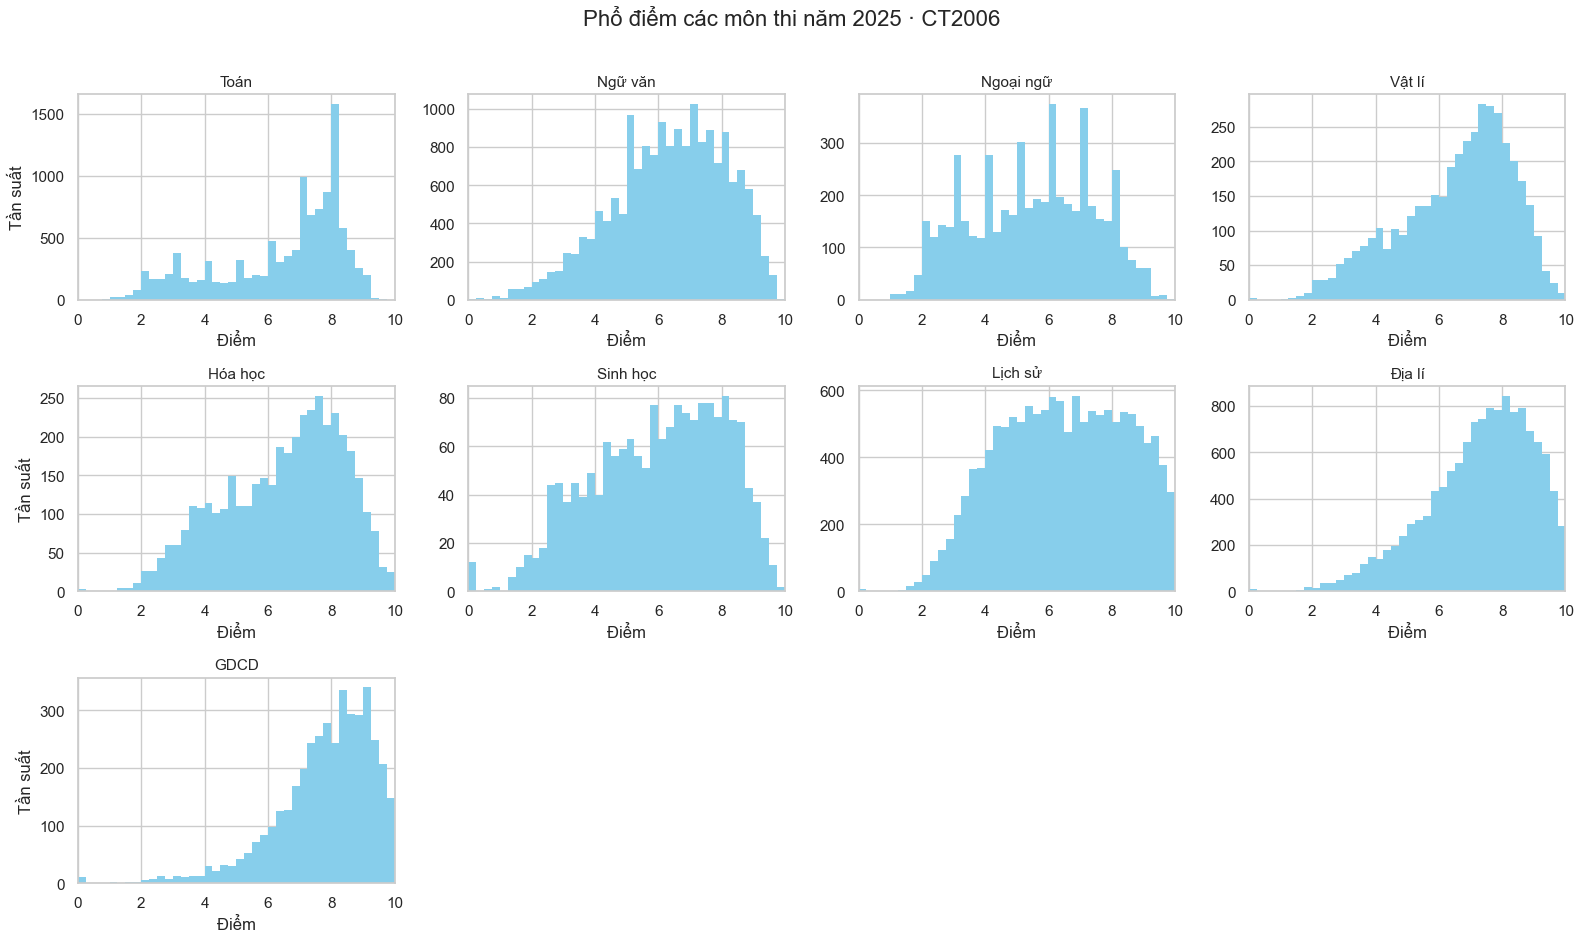

In [23]:
viz.plot_score_hist_grid(df, year=2025, chuong_trinh="2006")
plt.show()

**Nhận xét, phổ điểm năm 2025, chương trình 2006.**

Đây là nhóm thí sinh tự do thi theo đề chương trình 2006 trong năm 2025, với quy mô rất nhỏ (khoảng 22 nghìn thí sinh) và tỷ lệ dự thi từng môn thấp. Do số lượng ít, phổ điểm các môn gồ ghề và nhiễu hơn nhiều so với các năm trước, vì vậy chỉ nên xem xét ở mức xu hướng chung, không so sánh trực tiếp về tần suất với các năm có quy mô hàng triệu thí sinh.

Về hình dạng, phổ điểm vẫn giữ các đặc trưng quen thuộc của đề chương trình 2006. Toán và Ngoại ngữ tiếp tục có hiện tượng răng cưa rõ rệt do đặc thù thi trắc nghiệm. Ngoại ngữ vẫn lệch về vùng điểm thấp và phân tán rộng. GDCD nghiêng hẳn về phía điểm cao, tập trung ở khoảng 8 đến 10.

Điểm khác biệt đáng chú ý là mặt bằng điểm của nhóm này nhìn chung thấp hơn và phân tán hơn so với thí sinh chính quy các năm trước, thể hiện ở phần đuôi điểm thấp dày hơn ở hầu hết các môn. Đặc điểm này phù hợp với tính chất của nhóm thí sinh tự do, vốn không đại diện cho mặt bằng chung của toàn bộ thí sinh dự thi.

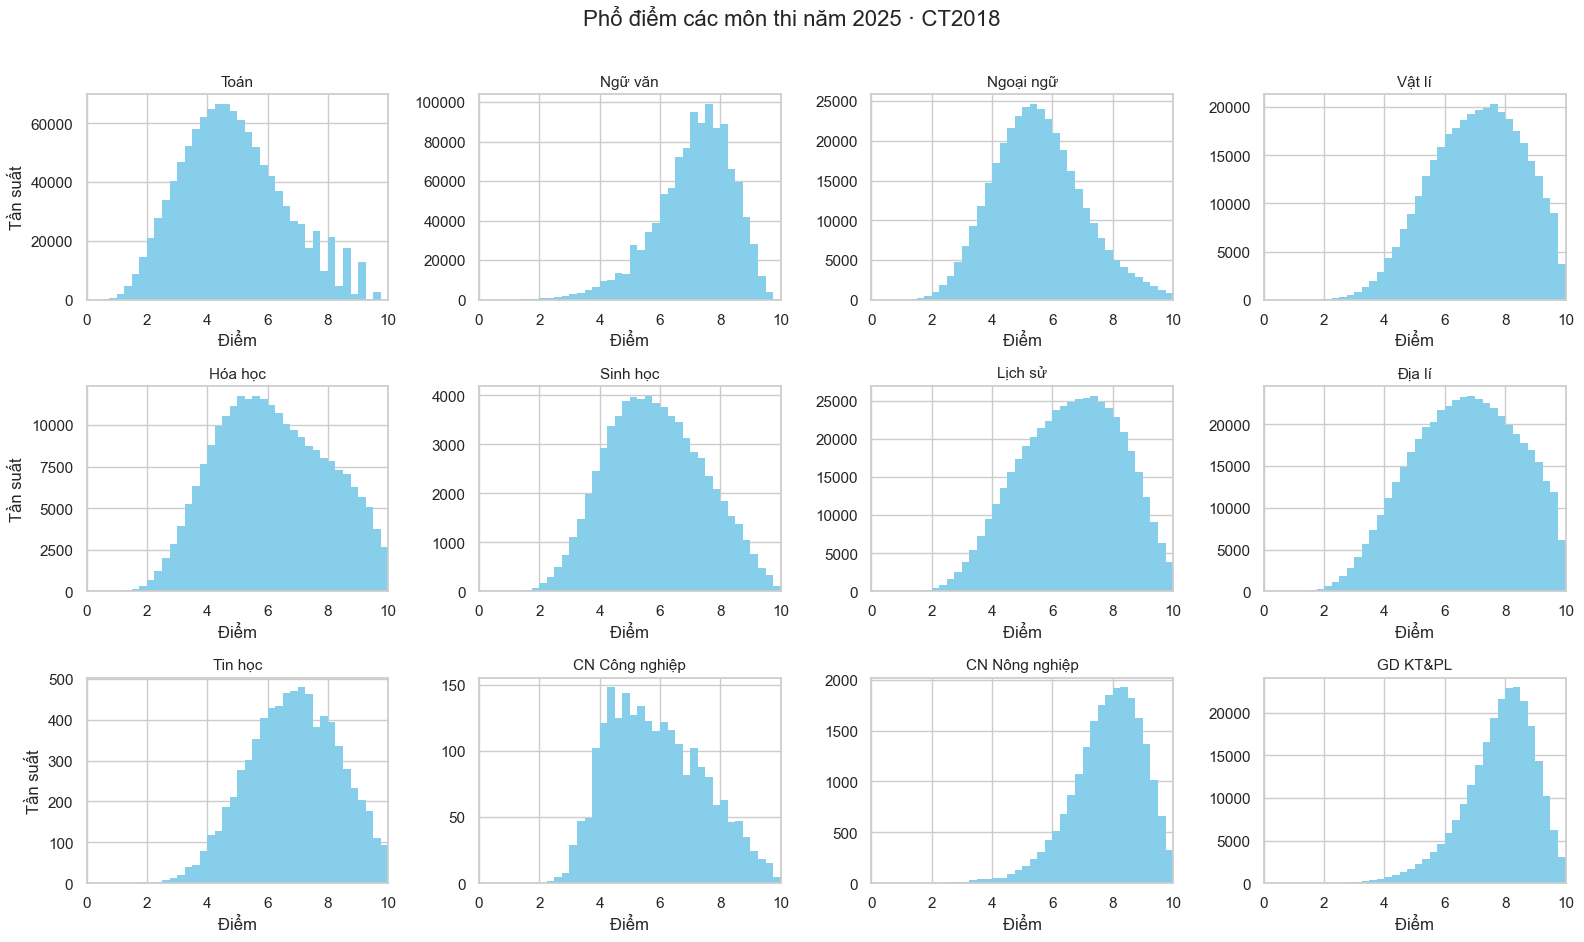

In [22]:
viz.plot_score_hist_grid(df, year=2025, chuong_trinh="2018")
plt.show()

**Nhận xét, phổ điểm năm 2025, chương trình 2018.**

Đây là năm đầu tiên kỳ thi tổ chức theo chương trình giáo dục phổ thông 2018, với cấu trúc môn thi và đề thi khác hẳn giai đoạn 2022 đến 2024, nên phổ điểm năm này được phân tích riêng và không so sánh trực tiếp về mặt bằng điểm với các năm trước. So với đề chương trình 2006, một thay đổi dễ thấy là hiện tượng răng cưa ở các môn trắc nghiệm gần như không còn, phổ điểm liền mạch và mượt hơn, phản ánh cách ra đề và tính điểm của chương trình mới.

Toán có sự thay đổi rõ rệt nhất: phổ điểm lệch hẳn về vùng điểm thấp, đỉnh rơi vào khoảng 4 đến 5 và đuôi phải mỏng dần, cho thấy mặt bằng điểm Toán năm 2025 thấp hơn đáng kể so với các năm trước. Ngoại ngữ và Vật lí có phân bố tương đối cân đối quanh khoảng 5 đến 7. Sinh học và Lịch sử trải rộng, đỉnh nằm ở vùng điểm trung bình khá.

Ở chiều ngược lại, Ngữ văn và nhóm môn mới gồm Công nghệ nông nghiệp và Giáo dục kinh tế và pháp luật đều lệch mạnh về phía điểm cao, tập trung quanh khoảng 8 đến 9. Các môn mới còn lại như Tin học và Công nghệ công nghiệp có quy mô dự thi rất nhỏ, phổ điểm nhiễu hơn và chỉ mang tính tham khảo.

Nhìn chung, năm 2025 cho thấy sự phân hóa khá rõ giữa các môn: trong khi Toán có mặt bằng điểm thấp thì nhiều môn xã hội và môn mới lại nghiêng về vùng điểm cao. Đây là đặc điểm đáng lưu ý của năm bản lề, cần được diễn giải trong bối cảnh thay đổi chương trình thay vì so sánh cơ học với các năm trước.

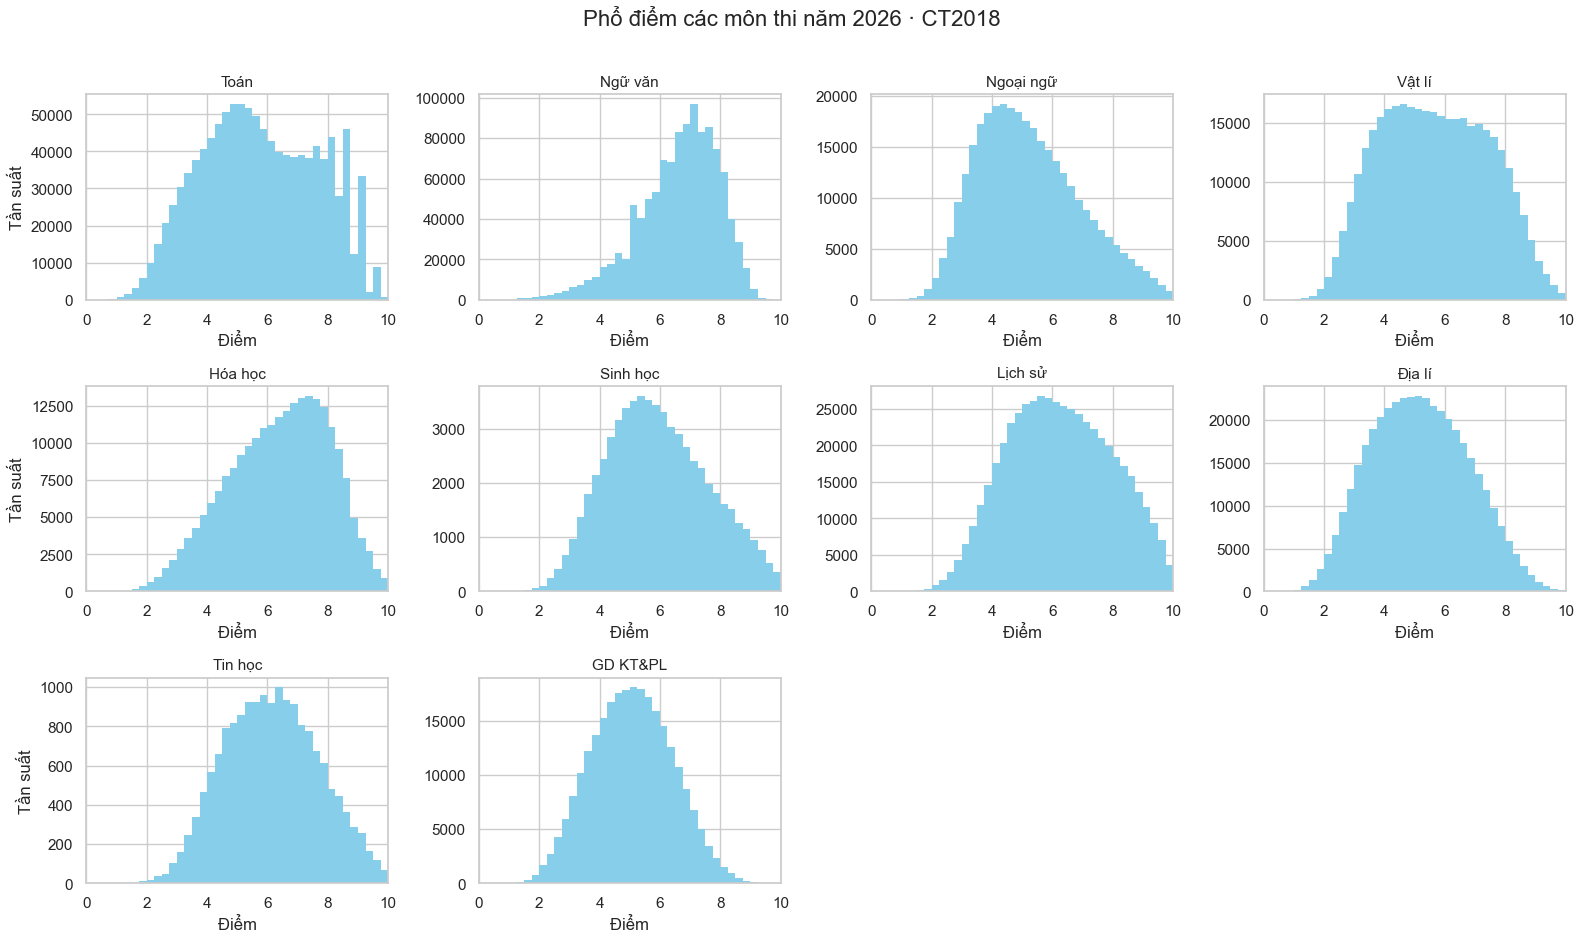

In [11]:
viz.plot_score_hist_grid(df, year=2026, chuong_trinh="2018")
plt.show()

**Nhận xét**

Phổ điểm của đa số môn trong **CT2018 năm 2026** tập trung chủ yếu ở vùng **trung bình đến khá (khoảng 4–7 điểm)**; điểm quá thấp và điểm tuyệt đối xuất hiện rất ít.

**Ngữ văn** có phân bố khá tập trung, đỉnh nằm khoảng **6.5–7.0**, cho thấy mặt bằng điểm tương đối ổn định và ít phân tán hơn nhiều môn khác.

**Toán** có phổ rộng hơn, tập trung nhiều ở khoảng **4–8 điểm**, cho thấy mức độ phân hóa tương đối rõ; nhóm điểm trung bình và khá chiếm ưu thế.

**Ngoại ngữ** lệch nhiều về vùng **điểm thấp-trung bình**, chủ yếu quanh **3–6 điểm**, phản ánh đây là một trong những môn có mặt bằng điểm thấp hơn so với Toán và Ngữ văn.

Trong nhóm KHTN:
  - **Vật lí** có phổ khá trải đều, nhiều thí sinh đạt khoảng **4–8 điểm**.
  - **Hóa học** nghiêng nhiều hơn về vùng **6–8 điểm**, cho thấy mặt bằng điểm khá tốt.
  - **Sinh học** tập trung quanh **5–7 điểm**, nhưng phần đuôi trải dài hơn về phía điểm cao, thể hiện độ phân tán tương đối lớn.

Trong nhóm KHXH:
  - **Lịch sử** tập trung chủ yếu ở khoảng **5–7 điểm**, ít điểm quá thấp.
  - **Địa lí** có dạng gần chuẩn hơn, đỉnh quanh **5–6 điểm**, khá cân đối.

Các môn mới như **Tin học** và **GD KT&PL** cũng chủ yếu tập trung ở vùng **trung bình-khá**:
  - **Tin học** có đỉnh khoảng **5.5–6.5 điểm**.
  - **GD KT&PL** tập trung quanh **4.5–5.5 điểm**, mặt bằng thấp hơn Tin học một chút.

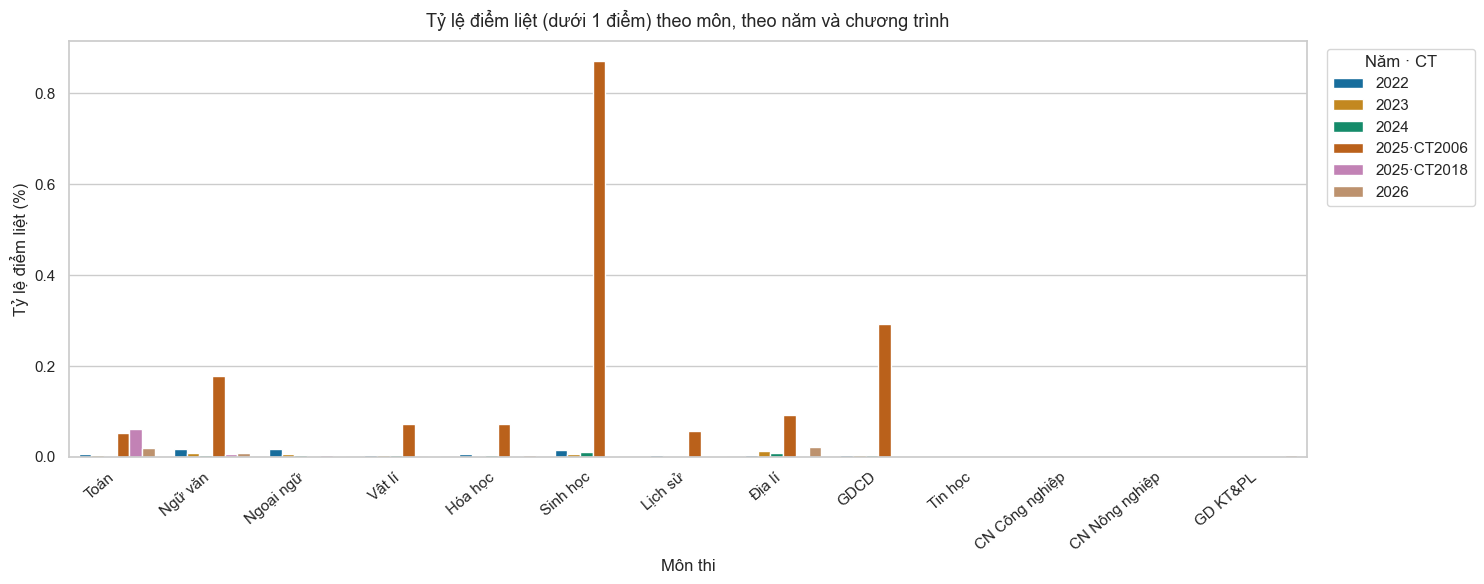

In [16]:
viz.plot_fail_rate_by_subject(df)
plt.show()

**Nhận xét, tỷ lệ điểm liệt theo môn**

- Ở các năm **2022, 2023, 2024** và cả **2026**, tỷ lệ điểm liệt nhìn chung **rất thấp**, đa số môn gần như sát mức **0%**. Điều này cho thấy hiện tượng thí sinh bị điểm liệt là **không phổ biến** trong nhóm dự thi chính quy.
- Điểm khác biệt rõ nhất nằm ở **nhóm 2025 - CT2006**. Tỷ lệ điểm liệt của nhóm này **cao vượt trội** ở nhiều môn, nổi bật nhất là **Sinh học** (xấp xỉ **0.87%**), tiếp theo là **GDCD** (khoảng **0.29%**) và **Ngữ văn** (khoảng **0.18%**). Một số môn khác như **Vật lí, Hóa học, Lịch sử, Địa lí** cũng cao hơn hẳn các năm còn lại.
- Kết quả trên phù hợp với đặc điểm của nhóm **thí sinh tự do/thi lại** theo chương trình cũ: mặt bằng điểm phân tán hơn và tỷ lệ điểm rất thấp xuất hiện nhiều hơn, nên **không nên gộp chung** với nhóm chính quy khi diễn giải.
- Với **2025 - CT2018**, tỷ lệ điểm liệt vẫn ở mức **thấp**, chỉ nhô lên nhẹ ở một vài môn như **Toán** và **Ngữ văn**, nhưng vẫn thấp hơn rất nhiều so với **2025 - CT2006**.
- Xét theo môn, **Sinh học** là môn có mức điểm liệt nổi bật nhất do bị kéo lên mạnh ở **2025 - CT2006**. Ngoài ra, **Ngữ văn** và **GDCD** cũng là hai môn có mức tăng tương đối rõ trong nhóm này.
- **2026** không cho thấy dấu hiệu bất thường mới: tỷ lệ điểm liệt vẫn duy trì rất thấp, chỉ xuất hiện nhích nhẹ ở một vài môn nhưng không tạo thành xu hướng đáng lo ngại.

## 3. Xu hướng qua năm
Theo dõi sự biến động của điểm trung bình qua giai đoạn 2022-2024 và năm bản lề 2025.

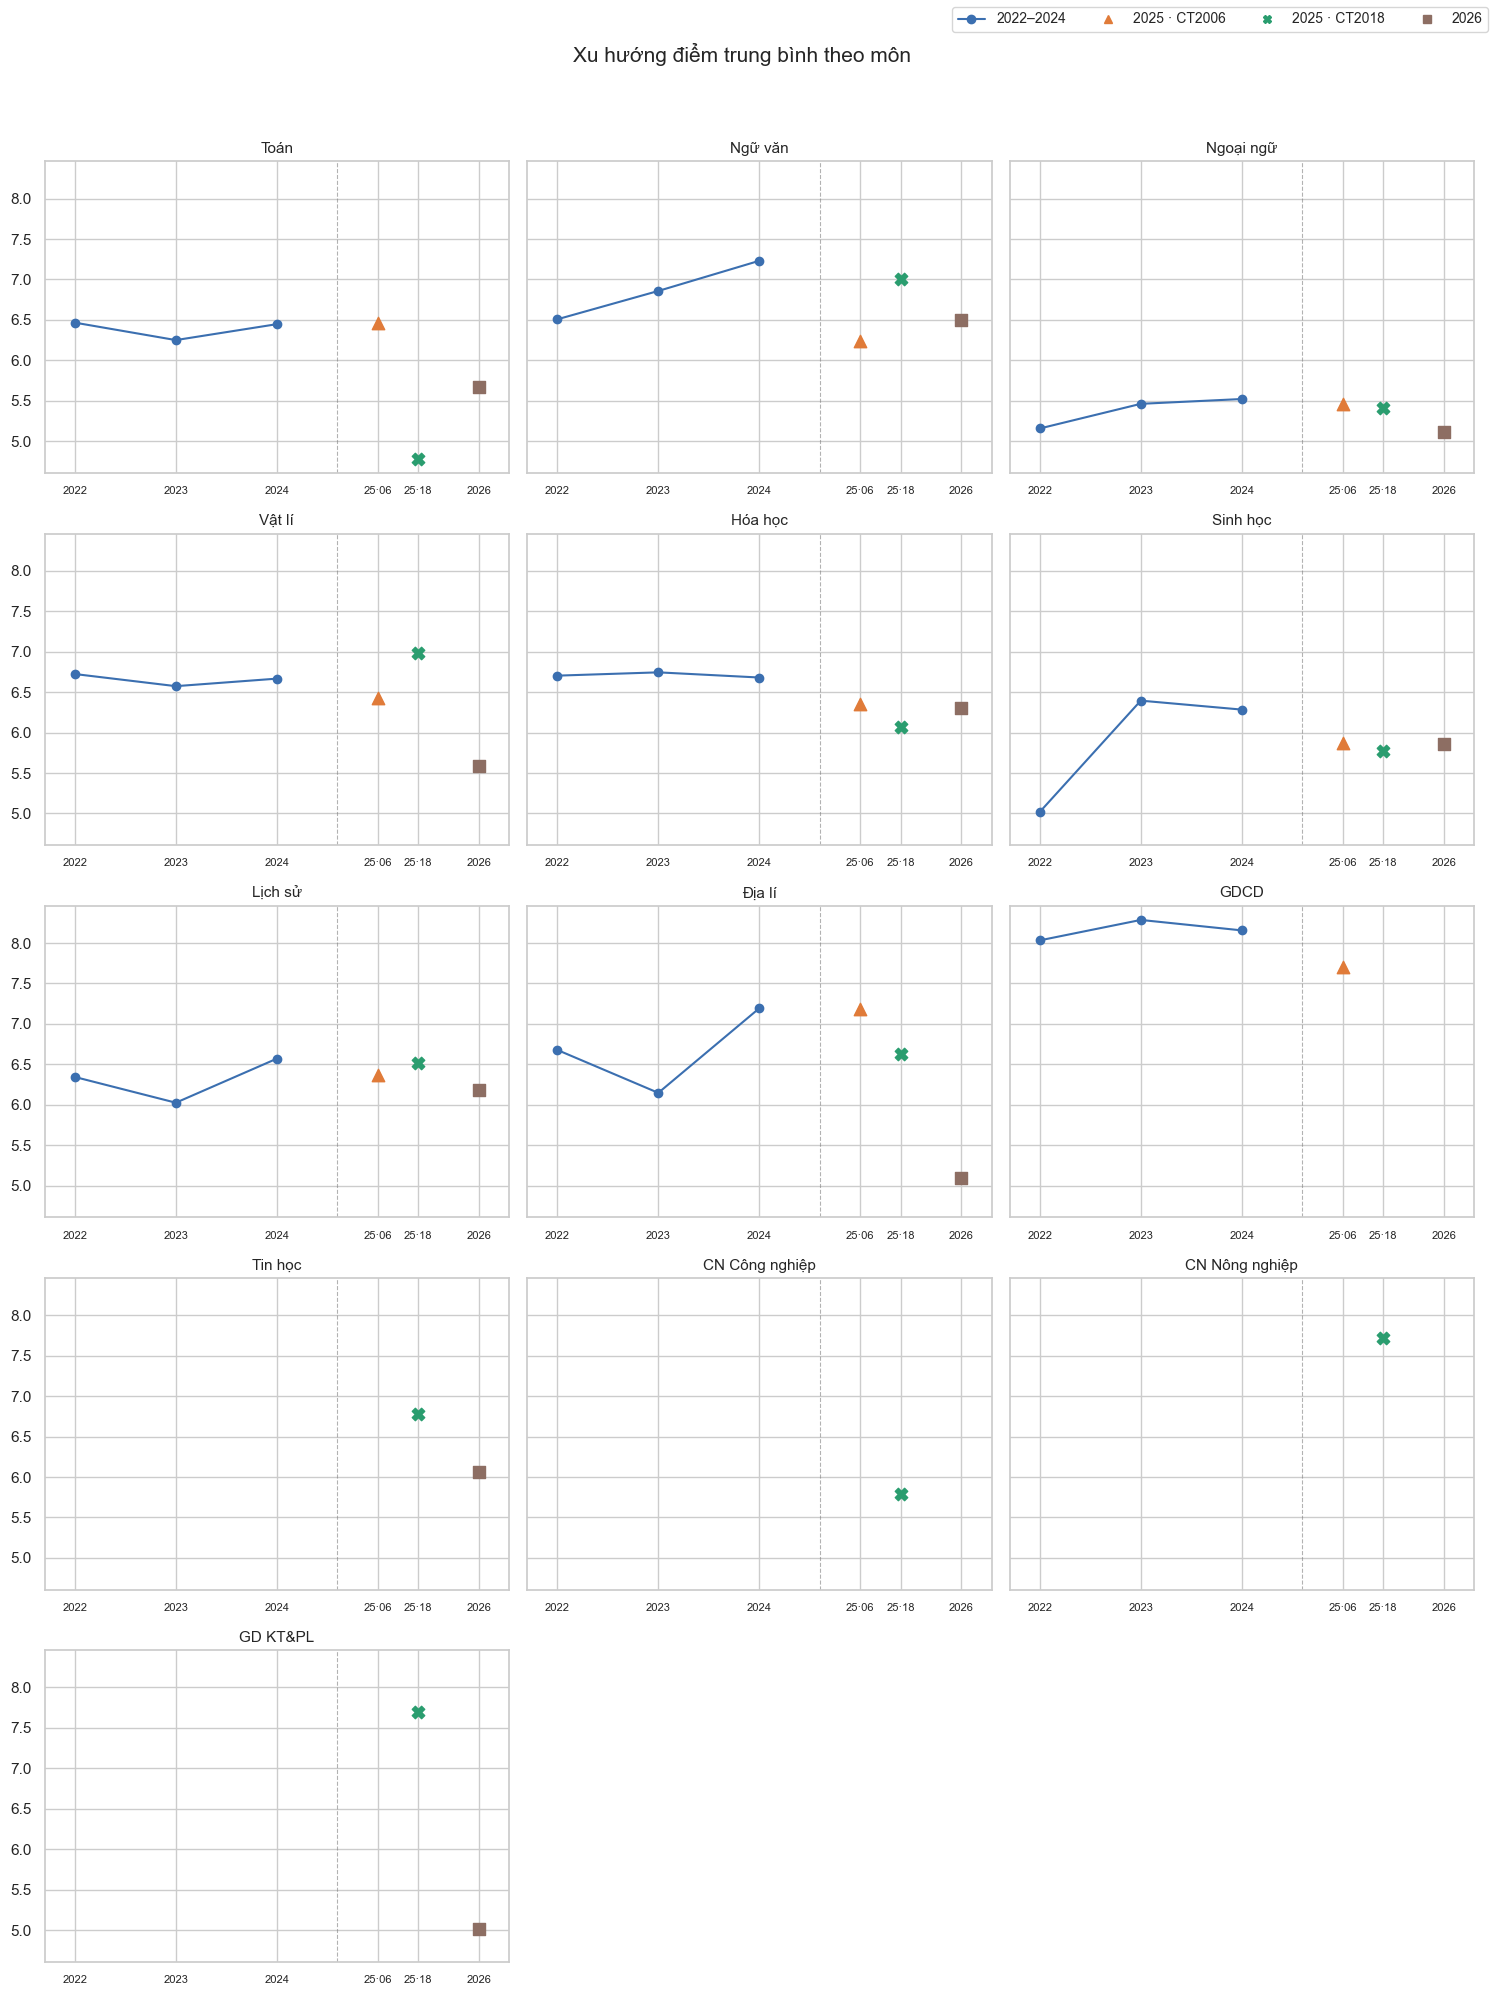

In [18]:
viz.plot_trend_2022_2024(df, stat="mean")
plt.show()

**Nhận xét, xu hướng điểm trung bình theo môn**

- Giai đoạn **2022–2024**, điểm trung bình của phần lớn môn học khá ổn định, chủ yếu dao động trong khoảng **5–7 điểm**. Một số môn có xu hướng tăng nhẹ như **Ngữ văn**, **Ngoại ngữ** và **Lịch sử**, trong khi **GDCD** luôn nằm trong nhóm có điểm trung bình cao nhất.
- **GDCD** nổi bật với mặt bằng điểm rất cao trong giai đoạn cũ, khoảng trên **8 điểm**; ngược lại, **Ngoại ngữ** là môn có điểm trung bình thấp hơn tương đối, chỉ quanh **5–5.5 điểm**.
- **Năm 2025** là giai đoạn chuyển tiếp nên được tách riêng theo hai chương trình. Nhìn chung, nhóm **CT2018** có điểm trung bình **cao hơn CT2006** ở nhiều môn như **Ngữ văn, Vật lí, Lịch sử** và các môn mới như **Tin học, GD KT&PL, CN Nông nghiệp**.
- **Toán** là môn biến động mạnh nhất: từ mức khoảng **6.2–6.5** trong **2022–2024**, xuống còn khoảng **4.8** ở **2025 - CT2018**, rồi phục hồi lên khoảng **5.7** trong **2026**. Đây là một trong những thay đổi đáng chú ý nhất trên biểu đồ.
- Với các môn khoa học tự nhiên, **Vật lí** giữ mặt bằng khá tốt ở **2025 - CT2018** nhưng giảm rõ ở **2026**; **Hóa học** và **Sinh học** cũng có xu hướng thấp hơn giai đoạn **2022–2024**.
- Ở nhóm khoa học xã hội, **Lịch sử** tương đối ổn định, nhưng **Địa lí** giảm mạnh trong **2026** xuống gần **5 điểm**, thấp hơn đáng kể so với các năm trước và cả hai nhóm năm 2025.
- Các môn mới của chương trình **CT2018** xuất hiện với mức điểm trung bình khá phân hóa:
  - **GD KT&PL** và **CN Nông nghiệp** có mặt bằng khá cao trong **2025 - CT2018**
  - **Tin học** ở mức khá
  - **CN Công nghiệp** thấp hơn tương đối
  - Sang **2026**, các môn này nhìn chung đều giảm, đặc biệt **GD KT&PL** giảm khá mạnh.
- **2026** nhìn chung cho thấy mặt bằng điểm ở nhiều môn **thấp hơn 2025 - CT2018** và thấp hơn giai đoạn **2022–2024**, cho thấy sau năm chuyển đổi chương trình, kết quả thi vẫn còn biến động đáng kể giữa các môn.

## 4. Địa lý

So sánh sự khác biệt về kết quả thi giữa các tỉnh.

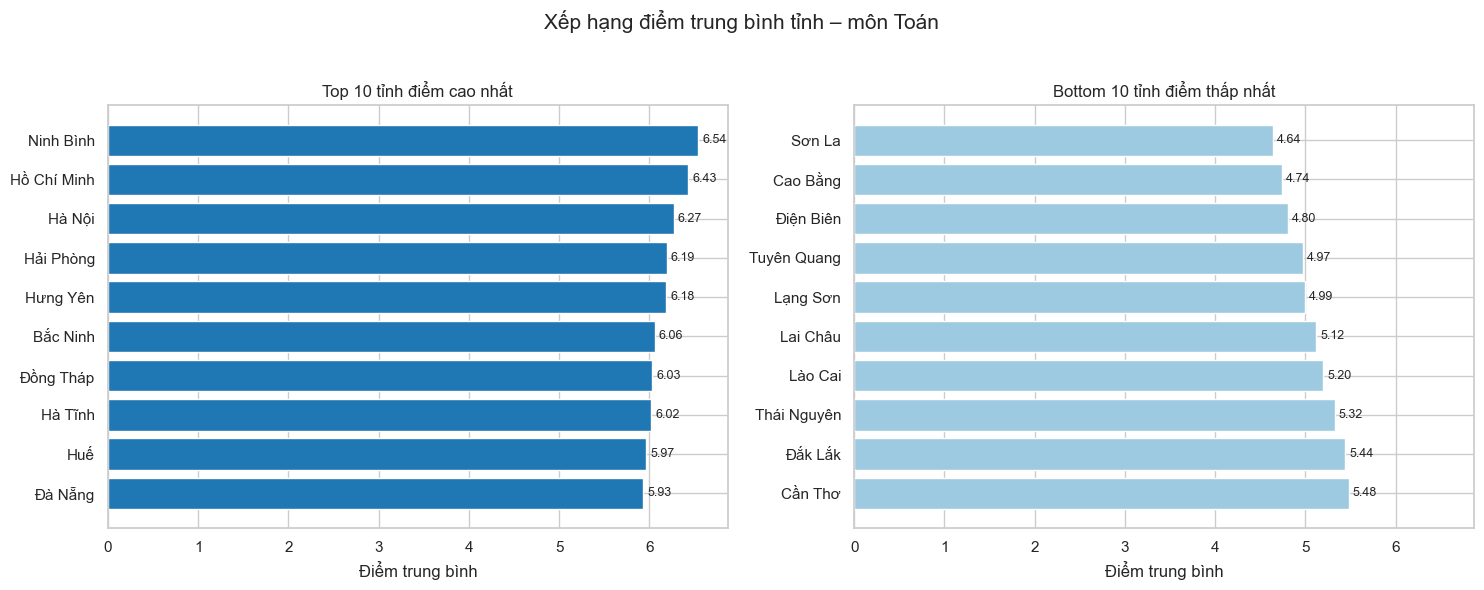

In [20]:
viz.plot_province_rank(df, subject="toan", top=10)
plt.show()

**Nhận xét, xếp hạng tỉnh theo điểm trung bình môn Toán**

- Điểm trung bình môn **Toán** có sự khác biệt khá rõ giữa các địa phương. Nhóm dẫn đầu gồm **Ninh Bình (6.54)**, **Hồ Chí Minh (6.43)**, **Hà Nội (6.27)**, **Hải Phòng (6.19)** và **Hưng Yên (6.18)**, cho thấy các tỉnh/thành ở **đồng bằng sông Hồng** và các **đô thị lớn** chiếm ưu thế rõ rệt.
- Nhóm cuối bảng gồm **Sơn La (4.64)**, **Cao Bằng (4.74)**, **Điện Biên (4.80)**, **Tuyên Quang (4.97)** và **Lạng Sơn (4.99)**. Phần lớn là các tỉnh **miền núi phía Bắc**, phản ánh mặt bằng điểm Toán ở khu vực này nhìn chung thấp hơn nhóm dẫn đầu.
- Khoảng cách giữa tỉnh cao nhất và thấp nhất là khoảng **1.90 điểm** trên thang 10, là mức chênh lệch đáng kể đối với một môn thi có quy mô dự thi rất lớn.
- Top 10 có mặt của cả **trung tâm lớn** như Hà Nội, Hồ Chí Minh, Hải Phòng và một số tỉnh có kết quả ổn định như **Bắc Ninh, Hà Tĩnh, Đồng Tháp, Huế, Đà Nẵng**. Trong khi đó, bottom 10 tập trung nhiều hơn ở các địa phương có điều kiện học tập và tiếp cận giáo dục không đồng đều hơn.
- Biểu đồ cho thấy sự phân hóa theo địa phương là khá rõ, nhưng đây mới là so sánh ở mức **mô tả**; để giải thích nguyên nhân sâu hơn cần kết hợp thêm các yếu tố như quy mô thí sinh, điều kiện kinh tế - xã hội và đặc điểm vùng miền.

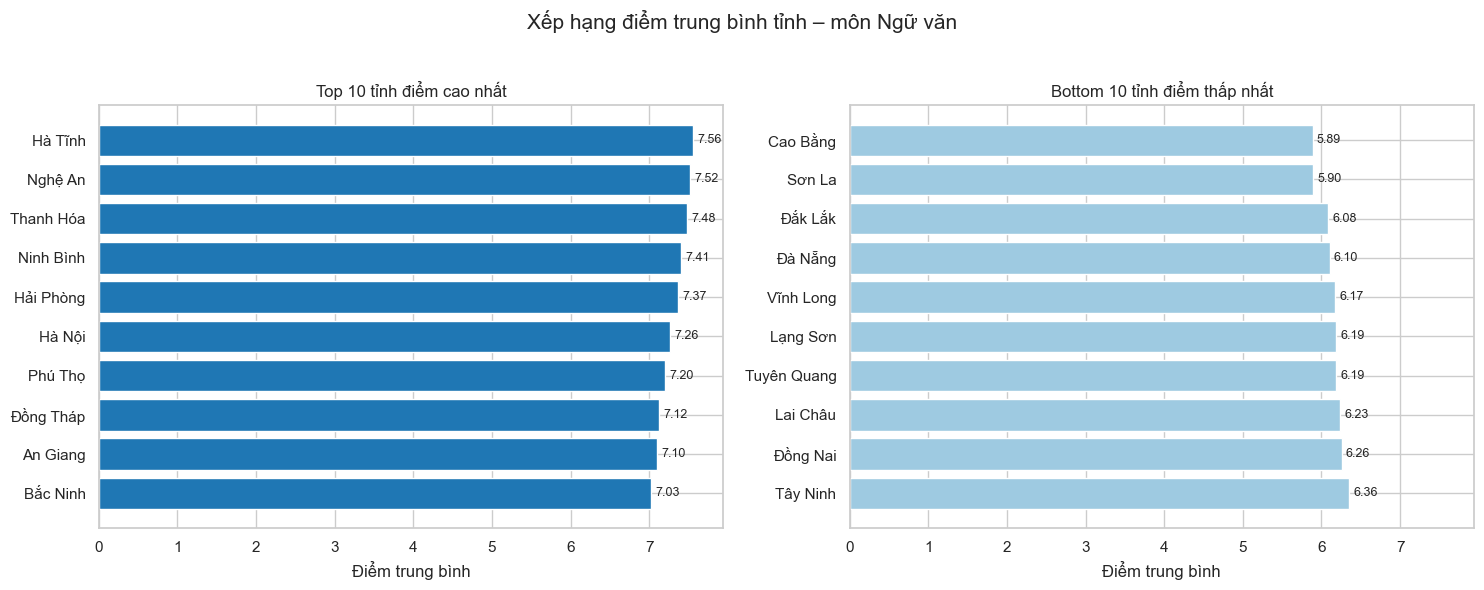

In [21]:
viz.plot_province_rank(df, subject="ngu_van", top=10)
plt.show()

**Nhận xét, xếp hạng tỉnh theo điểm trung bình môn Ngữ văn**

- Điểm trung bình **Ngữ văn** giữa các tỉnh có phân hóa, nhưng mức chênh lệch không quá lớn như ở môn Toán. Nhóm dẫn đầu gồm **Hà Tĩnh (7.56)**, **Nghệ An (7.52)**, **Thanh Hóa (7.48)**, **Ninh Bình (7.41)** và **Hải Phòng (7.37)**, cho thấy ưu thế nổi bật của nhiều địa phương ở **Bắc Trung Bộ** và **đồng bằng sông Hồng**.
- Nhóm cuối bảng gồm **Cao Bằng (5.89)**, **Sơn La (5.90)**, **Đắk Lắk (6.08)**, **Đà Nẵng (6.10)** và **Vĩnh Long (6.17)**. So với nhóm đầu, mặt bằng điểm ở các tỉnh này thấp hơn rõ rệt nhưng vẫn chủ yếu tập trung quanh mức **6 điểm**.
- Khoảng cách giữa tỉnh cao nhất và thấp nhất là khoảng **1.67 điểm**, nhỏ hơn mức chênh lệch của môn Toán, cho thấy điểm Ngữ văn giữa các địa phương có xu hướng **đồng đều hơn**.
- Top 10 có sự hiện diện của nhiều tỉnh không phải là các đô thị lớn nhất cả nước, như **Hà Tĩnh, Nghệ An, Thanh Hóa, Phú Thọ, An Giang**, cho thấy lợi thế ở môn Ngữ văn không hoàn toàn trùng với mô hình phân bố của môn Toán.
- Bottom 10 vẫn có sự xuất hiện của một số tỉnh miền núi như **Cao Bằng, Sơn La, Lạng Sơn, Tuyên Quang, Lai Châu**, nhưng đồng thời cũng có các địa phương thuộc vùng khác như **Đồng Nai, Tây Ninh, Vĩnh Long**, cho thấy sự phân hóa ở môn Ngữ văn mang tính **phân tán vùng miền hơn**, không tập trung quá mạnh vào một khu vực duy nhất.

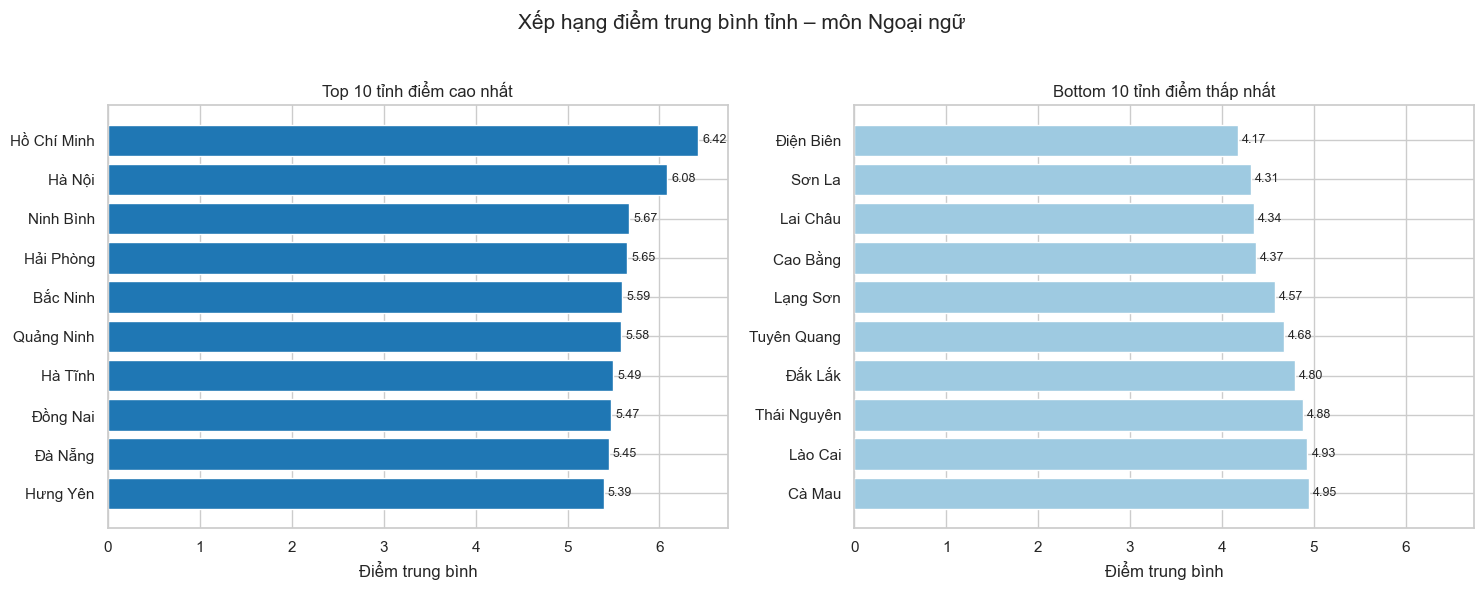

In [22]:
viz.plot_province_rank(df, subject="ngoai_ngu", top=10)
plt.show()
# chỉ tính N1 – tiếng Anh

**Nhận xét, xếp hạng tỉnh theo điểm trung bình môn Ngoại ngữ**

- Mặt bằng điểm trung bình **Ngoại ngữ** giữa các tỉnh nhìn chung thấp hơn rõ so với **Toán** và **Ngữ văn**, chủ yếu dao động trong khoảng **4–6.5 điểm**, cho thấy đây là môn có độ phân hóa tương đối lớn.
- Nhóm dẫn đầu gồm **Hồ Chí Minh (6.42)**, **Hà Nội (6.08)**, **Ninh Bình (5.67)**, **Hải Phòng (5.65)** và **Bắc Ninh (5.59)**. Hai đô thị lớn là **Hồ Chí Minh** và **Hà Nội** nổi bật rõ rệt, đặc biệt Hồ Chí Minh vượt khá xa phần còn lại.
- Nhóm cuối bảng gồm **Điện Biên (4.17)**, **Sơn La (4.31)**, **Lai Châu (4.34)**, **Cao Bằng (4.37)** và **Lạng Sơn (4.57)**. Phần lớn là các tỉnh **miền núi phía Bắc**, cho thấy sự chênh lệch vùng miền thể hiện rất rõ ở môn Ngoại ngữ.
- Khoảng cách giữa tỉnh cao nhất và thấp nhất là khoảng **2.25 điểm**, lớn hơn mức chênh lệch của môn **Ngữ văn** và cho thấy mức độ phân hóa địa phương ở môn này khá mạnh.
- Top 10 ngoài hai trung tâm lớn còn có nhiều địa phương thuộc **đồng bằng sông Hồng** và khu vực phát triển như **Hải Phòng, Bắc Ninh, Quảng Ninh, Hưng Yên**; trong khi bottom 10 nghiêng rõ về các tỉnh vùng cao và khó khăn hơn về điều kiện học tập, đặc biệt là tiếp cận môi trường học ngoại ngữ.

## 5. Tương quan
Khám phá mức độ tương quan tuyến tính giữa các cặp môn học.

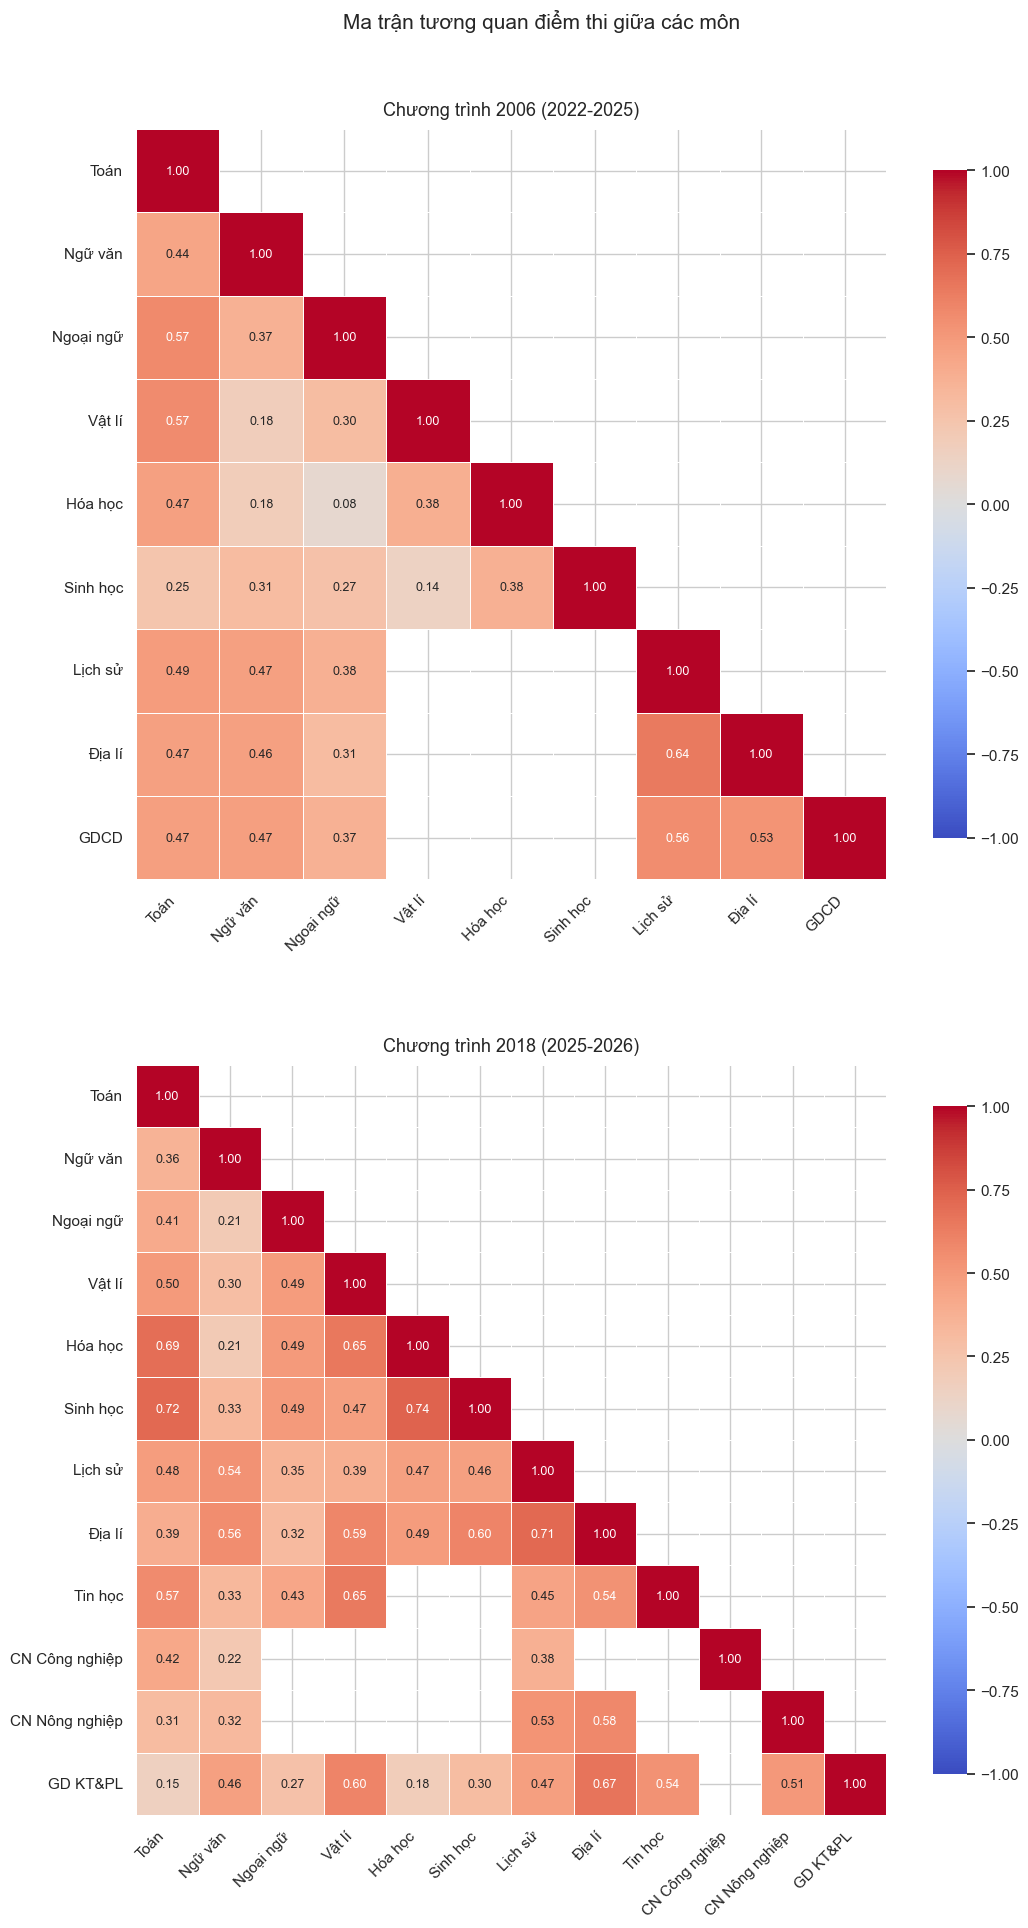

In [25]:
viz.plot_corr_heatmap(df)
plt.show()

**Nhận xét, tương quan điểm thi giữa các môn**

- Ma trận được tách theo **chương trình 2006** và **chương trình 2018** để tránh trộn hai nhóm thí sinh có cấu trúc môn thi khác nhau. Các ô để trắng là những cặp môn có **quá ít thí sinh cùng dự thi**, nên không đủ độ tin cậy để tính tương quan.
- Ở **chương trình 2006 (2022–2025)**, cấu trúc tương quan cho thấy khá rõ hai cụm môn theo tổ hợp:
  - Nhóm **KHXH** có mức gắn kết tương đối rõ, nổi bật là **Lịch sử – Địa lí (0.64)**, **Lịch sử – GDCD (0.56)** và **Địa lí – GDCD (0.53)**.
  - Nhóm **KHTN** liên kết yếu hơn đáng kể: **Vật lí – Hóa học (0.38)**, **Hóa học – Sinh học (0.38)**, còn **Vật lí – Sinh học** chỉ khoảng **0.14**.
- Ở **CT2006**, nhiều ô giữa nhóm **KHTN** và **KHXH** bị trống, phản ánh thực tế phần lớn thí sinh chỉ chọn **một tổ hợp**, nên rất ít quan sát chung giữa hai nhóm môn này.
- **Toán** trong **CT2006** là môn có tương quan dương với khá nhiều môn khác, mạnh nhất với **Ngoại ngữ** và **Vật lí** (đều khoảng **0.57**). Trong khi đó, **Sinh học** là môn có mức liên hệ yếu hơn với nhiều môn còn lại, cho thấy phổ điểm của môn này tương đối tách biệt hơn.

- Sang **chương trình 2018 (2025–2026)**, ma trận dày hơn và mức tương quan nhìn chung **cao, đồng đều hơn** so với CT2006. Điều này cho thấy trong chương trình mới, các nhóm môn được chọn có xu hướng tạo ra các cụm năng lực rõ ràng hơn.
- Ở nhóm **KHTN** của **CT2018**, mức tương quan tăng rõ:
  - **Hóa học – Sinh học: 0.74**
  - **Toán – Sinh học: 0.72**
  - **Toán – Hóa học: 0.69**
  - **Vật lí – Hóa học: 0.65**
  
  So với CT2006, nhóm tự nhiên trong CT2018 có độ gắn kết mạnh hơn hẳn.
- Nhóm **KHXH** trong **CT2018** cũng cho thấy liên hệ mạnh:
  - **Lịch sử – Địa lí: 0.71**
  - **Địa lí – GD KT&PL: 0.67**
  - **Lịch sử – GD KT&PL: 0.47**
  
  Trong đó, **Lịch sử – Địa lí** tiếp tục là một trong những cặp tương quan cao nhất bảng.
- Một số môn mới cũng có liên hệ đáng chú ý với các môn truyền thống, chẳng hạn **Tin học – Vật lí (0.65)**, **Tin học – Địa lí (0.54)**, hay **CN Nông nghiệp – Địa lí (0.58)**. Điều này cho thấy trong CT2018, mối liên hệ giữa các môn không chỉ gói gọn trong hai cụm tự nhiên và xã hội như trước.

- Nhìn chung, ở cả hai chương trình, các cặp môn **cùng nhóm** thường có tương quan cao hơn các cặp khác nhóm. Tuy vậy, hầu hết hệ số vẫn nằm dưới **0.8**, nên dù có liên hệ khá rõ, điểm số các môn vẫn phản ánh những thành phần năng lực **không hoàn toàn trùng nhau**.

## 6. Lựa chọn tổ hợp theo vùng
Quan sát tỉ lệ lựa chọn ban (KHTN/KHXH) đối với CT2006 và tỉ lệ đăng ký các môn tự chọn mới đối với CT2018.

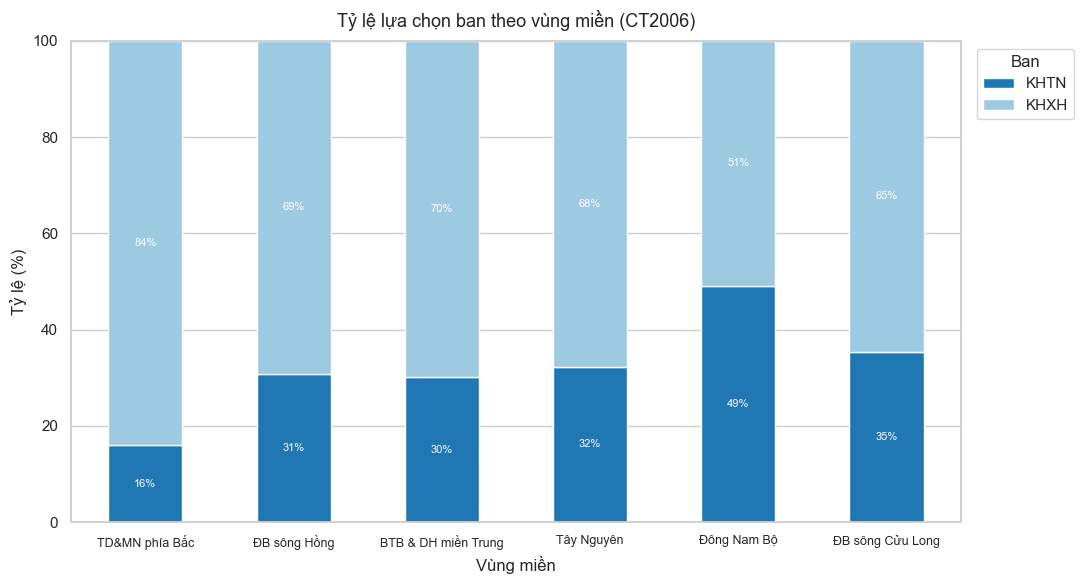

In [27]:
viz.plot_ban_by_region(df)
plt.show()

**Nhận xét, tỷ lệ lựa chọn ban theo vùng miền (CT2006)**

- Ở tất cả các vùng, **ban KHXH** đều chiếm tỷ trọng cao hơn **KHTN**, cho thấy xu hướng nghiêng về khối xã hội là nhất quán trên phạm vi cả nước trong chương trình **CT2006**.
- **Trung du và miền núi phía Bắc** là vùng nghiêng mạnh nhất về **KHXH**, với khoảng **84%** thí sinh chọn khối này và chỉ khoảng **16%** chọn **KHTN**. Đây là mức chênh lệch lớn nhất trong các vùng.
- **Đồng bằng sông Hồng**, **Bắc Trung Bộ và Duyên hải miền Trung** và **Tây Nguyên** có cơ cấu khá gần nhau, với tỷ lệ chọn **KHTN** chỉ quanh mức **30–32%**, tức khoảng **2/3 thí sinh** vẫn thiên về **KHXH**.
- **Đông Nam Bộ** là vùng có tỷ lệ chọn **KHTN** cao nhất, gần như cân bằng giữa hai ban, với khoảng **49% KHTN** và **51% KHXH**. **Đồng bằng sông Cửu Long** đứng kế tiếp, với khoảng **37%** thí sinh chọn **KHTN**.
- So sánh giữa các vùng cho thấy khu vực **phía Nam**, đặc biệt là **Đông Nam Bộ**, có xu hướng chọn **KHTN** mạnh hơn rõ rệt so với các vùng còn lại; trong khi **miền núi phía Bắc** nghiêng rất rõ về **KHXH**.
- Mẫu hình này gợi ý rằng lựa chọn ban học không chỉ phản ánh sở thích môn học, mà còn có thể liên quan đến khác biệt về **điều kiện học tập**, **cơ hội tiếp cận các môn tự nhiên** và **định hướng xét tuyển/nghề nghiệp** giữa các vùng miền.

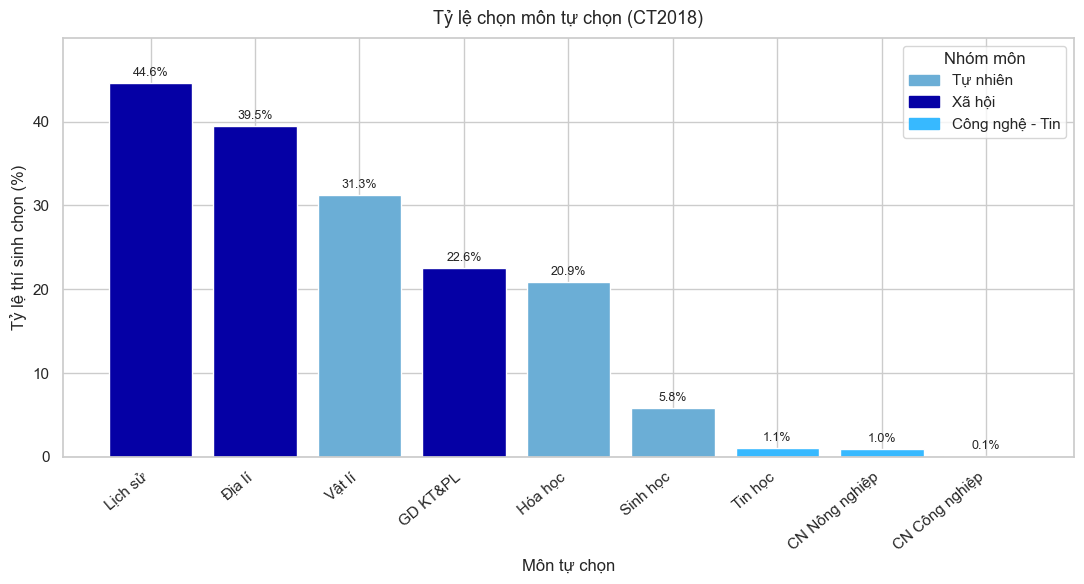

In [30]:
viz.plot_ct2018_subject_uptake(df)
plt.show()

**Nhận xét, tỷ lệ chọn môn tự chọn (CT2018)**

- Cơ cấu chọn môn tự chọn trong **CT2018** cho thấy xu hướng tập trung rất rõ vào một số môn truyền thống. Hai môn được chọn nhiều nhất là **Lịch sử (44.6%)** và **Địa lí (39.5%)**, bỏ khá xa các môn còn lại.
- Trong nhóm **KHTN**, **Vật lí (31.3%)** là môn được chọn nhiều nhất, cao hơn đáng kể so với **Hóa học (20.9%)** và đặc biệt là **Sinh học (5.8%)**. Điều này cho thấy ngay trong nhóm tự nhiên, mức độ hấp dẫn giữa các môn cũng chênh lệch khá mạnh.
- **GD KT&PL (22.6%)** là môn xã hội có tỷ lệ lựa chọn tương đối cao, đứng sau Lịch sử và Địa lí, cho thấy nhóm môn xã hội tiếp tục chiếm ưu thế trong chương trình mới.
- Ba môn thuộc nhóm **Công nghệ - Tin** có tỷ lệ chọn rất thấp: **Tin học (1.1%)**, **CN Nông nghiệp (1.0%)** và **CN Công nghiệp (0.1%)**. Đây là nhóm môn gần như chỉ xuất hiện ở một bộ phận rất nhỏ thí sinh.
- Nhìn tổng thể, thí sinh **CT2018** vẫn ưu tiên rõ rệt các môn quen thuộc và phổ biến trong xét tuyển, đặc biệt là **Lịch sử, Địa lí, Vật lí**; trong khi các môn mới chưa tạo được mức độ lựa chọn đáng kể.
- Tỷ lệ chọn quá thấp ở một số môn như **Tin học** hay **Công nghệ** cũng đồng nghĩa với việc các phân tích sâu hơn về phổ điểm hoặc tương quan của các môn này cần được diễn giải thận trọng, vì quy mô thí sinh dự thi còn rất nhỏ.